<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Image Feature exercise 

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Jan
- LastName: Hoegen
- MatriculationNumber: 82358
----------

In [18]:
import random
import numpy as np
from EITB712M.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
cifar10_dir = 'datasets/cifar-10-batches-py'

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [20]:
from EITB712M.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [21]:
from EITB712M.features import *

num_color_bins = 20 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension to allow training of the offset
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train MSVM on features
Using the multiclass SVM code developed in excercise "04_MSVM_Klassifier", train SVMs on top of the features extracted above; this should achieve better results than training MSVMs directly on top of raw pixels.

-----------
<span style="color:blue">**Copy the files "linear_classifier.py" and "linear_svm.py" from excercise "04_MSVM_Klassifier" to the folder classifier of this excercise.**</span>

-----------
<span style="color:blue">**Implement the hyperparameter tuning. You can also copy (and adapt) this from the MSVM excercise.**</span>

In [22]:
X_train_feats.shape

(49000, 165)

In [23]:
# Use the validation set to tune the learning rate and regularization strength

from EITB712M.classifiers.linear_classifier import LinearSVM

learning_rates = [1e-9, 1e-8, 1e-7]
regularization_strengths = [5e4, 5e5, 5e6,]

results = {}
best_val = -1
best_svm = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the MSVM; save    #
# the best trained classifer in best_svm. You might also want to play          #
# with different numbers of bins in the color histogram. If you are careful    #
# you should be able to get accuracy of near 0.44 on the validation set.       #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
# Obtain all possible combinations

learning_rates = [5e-8, 1e-7, 3e-7]
regularization_strengths = [1.5e4, 1.75e4, 2e4, 2.25e4, 2.5e4, 3.5e4, 4e4]

# Obtain all possible combinations
grid_search = [ (lr,rg) for lr in learning_rates for rg in regularization_strengths ]

for lr, rg in grid_search:
    # Create a new SVM instance
    svm = LinearSVM()

    train_loss = svm.train(X_train_feats, y_train, learning_rate=lr, reg=rg,
                      num_iters=1500, verbose=False)
    
    y_train_pred = svm.predict(X_train_feats)
    train_accuracy = np.mean(y_train_pred == y_train)

    y_val_pred = svm.predict(X_val_feats)
    val_accuracy = np.mean(y_val_pred == y_val)

    results[(lr,rg)] = (train_accuracy, val_accuracy)
    if best_val < val_accuracy:
        best_val = val_accuracy
        best_svm = svm

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 5.000000e-08 reg 1.500000e+04 train accuracy: 0.129102 val accuracy: 0.146000
lr 5.000000e-08 reg 1.750000e+04 train accuracy: 0.147633 val accuracy: 0.152000
lr 5.000000e-08 reg 2.000000e+04 train accuracy: 0.165245 val accuracy: 0.170000
lr 5.000000e-08 reg 2.250000e+04 train accuracy: 0.185571 val accuracy: 0.192000
lr 5.000000e-08 reg 2.500000e+04 train accuracy: 0.207510 val accuracy: 0.217000
lr 5.000000e-08 reg 3.500000e+04 train accuracy: 0.327449 val accuracy: 0.319000
lr 5.000000e-08 reg 4.000000e+04 train accuracy: 0.375531 val accuracy: 0.381000
lr 1.000000e-07 reg 1.500000e+04 train accuracy: 0.353980 val accuracy: 0.347000
lr 1.000000e-07 reg 1.750000e+04 train accuracy: 0.382837 val accuracy: 0.371000
lr 1.000000e-07 reg 2.000000e+04 train accuracy: 0.403224 val accuracy: 0.413000
lr 1.000000e-07 reg 2.250000e+04 train accuracy: 0.422245 val accuracy: 0.431000
lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.418980 val accuracy: 0.425000
lr 1.000000e-07 reg 3.500000

In [24]:
# Evaluate your trained SVM on the test set: you should be able to get at least 0.40
y_test_pred = best_svm.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.427


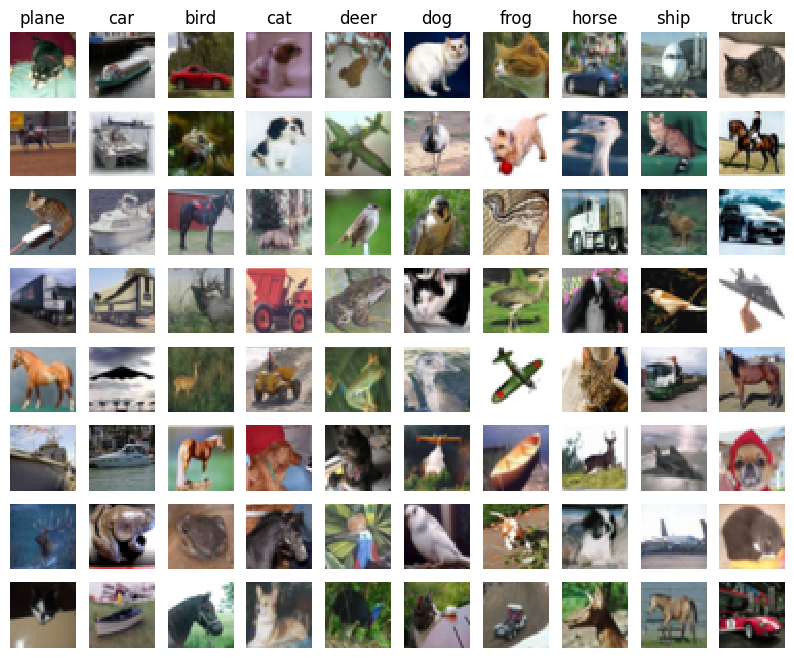

In [25]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer:}$

> - manchmal ist die Fehlerursache klar erkennbar: Heller Vogel vor blauem Himmel wird als Flugzeug erkannt. Katze vor Aquarium als Schiff. 
> - Häufig ist jedoch keine klare Fehlerursache erkennbar.




## Neural Network on image features

In the excercise "05_NeuralNet" we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels. 

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves more than 60% classification accuracy.

-----------
<span style="color:blue">**Copy the file "neural_net.py" from excercise "05_NeuralNet" to the folder classifier of this excercise.**</span>

-----------
<span style="color:blue">**Implement the hyperparameter tuning. You can also copy  (and adapt) this from the NeuralNet excercise.**</span>

In [26]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]
print(X_train_feats.shape)

(49000, 165)
(49000, 164)


In [42]:
from EITB712M.classifiers.neural_net import TwoLayerNet

input_size = X_train_feats.shape[1]
num_classes = 10
num_iterations = 1000
num_tests = 30
best_net = None
best_val = -1
best_train = -1

# Set a seed for results reproduction
np.random.seed(0)

# generate random hyperparameters given ranges for each of them
def generate_random_hyperparams(lr_min, lr_max, reg_min, reg_max, h_min, h_max):
    lr = 10**np.random.uniform(lr_min,lr_max)
    reg = 10**np.random.uniform(reg_min,reg_max)
    hidden = np.random.randint(h_min, h_max)
    return lr, reg, hidden

# get random hyperparameters given arrays of potential values
def random_search_hyperparams(lr_values, reg_values, h_values):
    lr = lr_values[np.random.randint(0,len(lr_values))]
    reg = reg_values[np.random.randint(0,len(reg_values))]
    hidden = h_values[np.random.randint(0,len(h_values))]
    return lr, reg, hidden

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

hidden_size = 800  
num_iters = 15000  
batch_size = 200
learning_rate_decay = 0.98


for i in range(20):
    lr, reg, hidden_size = generate_random_hyperparams(-2.2, -1.9, -4, -3, 700, 1000)

    net = TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

    stats = net.train(
        X_train_feats, y_train,
        X_val_feats, y_val,
        num_iters=num_iters,
        batch_size=batch_size,
        learning_rate=lr,
        learning_rate_decay=learning_rate_decay,
        reg=reg,
        verbose=False
    )
    
    train_accuracy = (net.predict(X_train_feats) == y_train).mean()
    val_accuracy = (net.predict(X_val_feats) == y_val).mean()

    if val_accuracy > best_val:
        best_val = val_accuracy
        best_train = train_accuracy
        best_net = net
        best_stats = stats

    print('lr %e reg %e hid %d  train accuracy: %f val accuracy: %f' % (
                lr, reg, hidden_size, train_accuracy, val_accuracy))
print('best validation accuracy achieved: %f' % best_val)
print('best train accuracy achieved: %f' % best_train)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****


lr 9.218156e-03 reg 5.190263e-04 hid 951  train accuracy: 0.544959 val accuracy: 0.533000
lr 9.253788e-03 reg 2.965345e-04 hid 959  train accuracy: 0.557571 val accuracy: 0.540000
lr 7.472788e-03 reg 2.768083e-04 hid 718  train accuracy: 0.565571 val accuracy: 0.552000
lr 8.879943e-03 reg 2.262450e-04 hid 959  train accuracy: 0.575265 val accuracy: 0.544000
lr 1.031422e-02 reg 3.724627e-04 hid 833  train accuracy: 0.559265 val accuracy: 0.532000
lr 1.161470e-02 reg 1.430502e-04 hid 813  train accuracy: 0.600388 val accuracy: 0.553000
lr 6.696808e-03 reg 4.828479e-04 hid 756  train accuracy: 0.548612 val accuracy: 0.528000
lr 1.018297e-02 reg 2.628375e-04 hid 736  train accuracy: 0.573204 val accuracy: 0.544000
lr 1.187283e-02 reg 1.490905e-04 hid 736  train accuracy: 0.599102 val accuracy: 0.555000
lr 9.251176e-03 reg 4.056636e-04 hid 989  train accuracy: 0.547633 val accuracy: 0.526000
lr 1.194772e-02 reg 1.440637e-04 hid 714  train accuracy: 0.604061 val accuracy: 0.576000
lr 1.10516

In [44]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 55% accuracy.

test_acc = (best_net.predict(X_test_feats) == y_test).mean()
print(test_acc)

0.547


In [45]:
import helpers

helpers.prepare_submission(additional=[r"EITB712M", r"datasets\cifar-10-batches-py"])

'Abgaben\\82358_Hoegen_Jan_06_20251022_2342.zip'